a × b: [0. 0. 1.]
np.cross: [0. 0. 1.]
b × a: [ 0.  0. -1.]
|v1 × v2|: 12.0
Perpendicular to a: 0.0
Perpendicular to b: 0.0
P (change-of-basis): [[ 2. -1.]
 [ 1.  1.]]
P_inv: [[ 0.3333  0.3333]
 [-0.3333  0.6667]]
Jennifer [1,2] → your coords: [0. 3.]
Round trip back: [1. 2.]
Rotation in standard coords: [[ 0.707 -0.707]
 [ 0.707  0.707]]
Same rotation in Jennifer's coords: [[ 0.943 -0.471]
 [ 1.179  0.471]]


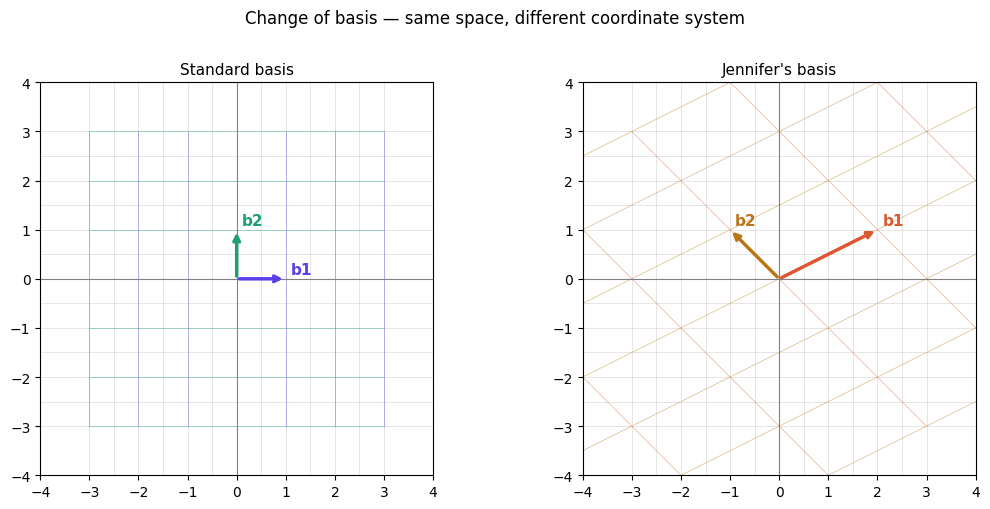

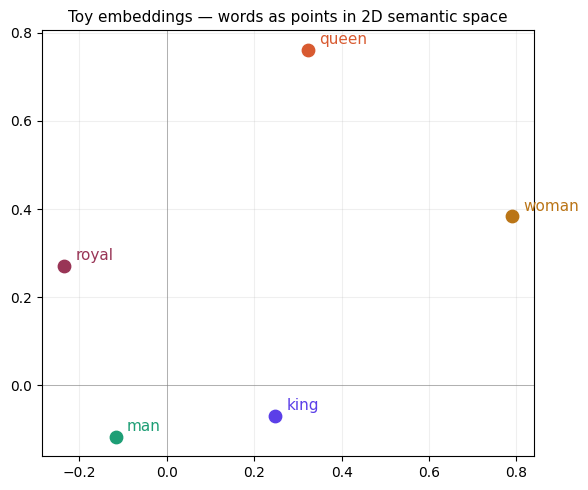

Save as day05_basis.ipynb and push to GitHub.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Cross product ─────────────────────────────────────
def cross_product(a, b):
    return np.array([
        a[1]*b[2] - a[2]*b[1],
        a[2]*b[0] - a[0]*b[2],
        a[0]*b[1] - a[1]*b[0]
    ])

a = np.array([1., 0., 0.])   # x-axis
b = np.array([0., 1., 0.])   # y-axis
c = cross_product(a, b)
print("a × b:", c)                        # [0, 0, 1] → z-axis ✓
print("np.cross:", np.cross(a, b))        # verify match
print("b × a:", cross_product(b, a))      # [0, 0, -1] → anti-commutative ✓

# Magnitude = area of parallelogram
v1 = np.array([3., 0., 0.])
v2 = np.array([0., 4., 0.])
print("|v1 × v2|:", np.linalg.norm(cross_product(v1, v2)))  # 12.0 (3×4 rectangle)

# Verify perpendicularity: dot(a×b, a) should be 0
print("Perpendicular to a:", np.dot(c, a).round(10))  # 0.0 ✓
print("Perpendicular to b:", np.dot(c, b).round(10))  # 0.0 ✓

# ── 2. Change of basis ───────────────────────────────────
# Jennifer's basis vectors (expressed in standard coordinates)
b1 = np.array([2., 1.])
b2 = np.array([-1., 1.])

# Change-of-basis matrix: columns are Jennifer's basis vectors
P = np.column_stack([b1, b2])
P_inv = np.linalg.inv(P)

print("P (change-of-basis):", P)
print("P_inv:", P_inv.round(4))

# Jennifer says point is at [1, 2] in her coordinates
jennifer_coords = np.array([1., 2.])
your_coords = P @ jennifer_coords
print("Jennifer [1,2] → your coords:", your_coords)  # [0, 3]

# Round trip: your coords back to Jennifer's
back = P_inv @ your_coords
print("Round trip back:", back.round(10))              # [1, 2] ✓

# Transform a transformation: same rotation in Jennifer's frame
theta = np.pi / 4   # 45 degrees
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

R_jennifer = P_inv @ R @ P   # same rotation in Jennifer's coords
print("Rotation in standard coords:", R.round(3))
print("Same rotation in Jennifer's coords:", R_jennifer.round(3))

# ── 3. Visualise — two coordinate systems ────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

def draw_basis(ax, P, label, c1, c2, title):
    # Standard grid (faint)
    for i in np.linspace(-3, 3, 13):
        ax.axhline(i, color='lightgray', lw=0.4)
        ax.axvline(i, color='lightgray', lw=0.4)
    # New basis vectors
    origin = np.zeros(2)
    ax.annotate('', xy=P[:,0], xytext=origin,
                arrowprops=dict(arrowstyle='->', color=c1, lw=2.5))
    ax.annotate('', xy=P[:,1], xytext=origin,
                arrowprops=dict(arrowstyle='->', color=c2, lw=2.5))
    ax.text(P[0,0]+0.1, P[1,0]+0.1, 'b1', color=c1, fontsize=11, fontweight='bold')
    ax.text(P[0,1]+0.1, P[1,1]+0.1, 'b2', color=c2, fontsize=11, fontweight='bold')
    # Grid lines in new basis
    for i in range(-3, 4):
        start = P @ np.array([i, -3.])
        end   = P @ np.array([i,  3.])
        ax.plot([start[0],end[0]], [start[1],end[1]], color=c1, lw=0.5, alpha=0.5)
        start = P @ np.array([-3., i])
        end   = P @ np.array([ 3., i])
        ax.plot([start[0],end[0]], [start[1],end[1]], color=c2, lw=0.5, alpha=0.5)
    ax.set_xlim(-4,4); ax.set_ylim(-4,4)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_title(title, fontsize=11)

I_std = np.eye(2)
draw_basis(axes[0], I_std, 'standard', '#5B3FE8', '#1D9E75', 'Standard basis')
draw_basis(axes[1], P,     'jennifer', '#D85A30', '#BA7517', "Jennifer's basis")

plt.suptitle('Change of basis — same space, different coordinate system', y=1.01)
plt.tight_layout()
plt.show()

# ── 4. Embedding intuition — change of basis in action ───
np.random.seed(42)
vocab_size = 5
embed_dim  = 2   # tiny for visualisation

# One-hot vectors (standard basis in vocab space)
one_hots = np.eye(vocab_size)
words = ['king', 'queen', 'man', 'woman', 'royal']

# Embedding matrix = change-of-basis matrix (random here, learned in real models)
E = np.random.randn(vocab_size, embed_dim) * 0.5

embeddings = one_hots @ E   # each word → dense vector

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#5B3FE8','#D85A30','#1D9E75','#BA7517','#993556']
for i, (word, emb) in enumerate(zip(words, embeddings)):
    ax.scatter(*emb, color=colors[i], s=80, zorder=5)
    ax.annotate(word, emb, textcoords="offset points",
                xytext=(8,4), fontsize=11, color=colors[i])
ax.set_title('Toy embeddings — words as points in 2D semantic space', fontsize=11)
ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print("Save as day05_basis.ipynb and push to GitHub.")